# 05 — Velocity-centered ζ dipole on real MDPL2 halos

**Exploratory twin of `scripts/plot_velocity_centered_dipole.py`.** Both this
notebook and that script call the same stage functions from
`dvcorr.pipeline.velocity_centered` — the single source of truth for this
pipeline (CLAUDE.md: notebooks are exploration only, "diagnostics that import
the real modules, never reimplement them"). Every code cell below just calls
one of those stage functions — `load_and_carve`, `draw_candidates`,
`run_estimator`, `box_number_density`, `normalize_result`, `make_figure`
— in sequence, so what you see here is exactly what
`python -m scripts.plot_velocity_centered_dipole` produces, one stage at a
time.

This measures the **velocity-centered** statistic ζ (Nusser 2017 eq. 23-24),
the mirror image of notebook 04's group-centered ξ_Tu: here a VELOCITY object
sits at the center and DENSITY tracers are counted in shells around it. Per
`dvcorr.conventions.nusser_multipole_sign`, ζ_ℓ = (−1)^ℓ ξ_Tu,ℓ — monopoles agree, but the
dipole flips sign. **Coherent infall therefore gives a POSITIVE ζ₁** here,
the opposite of notebook 04's negative ξ_Tu,1 (CLAUDE.md hard rule 2 states
the group-centered sign; this is its velocity-centered mirror, made explicit in
`dvcorr/estimators/shell_dipole.py`'s module docstring and pinned by the joint sign
gate in `tests/test_velocity_centered_dipole.py`).

## The polar axis follows the motion, not the line of sight

Each center's shell expansion is axed on

$$\hat z_\alpha = \mathrm{sign}(u_\alpha)\,\hat n_{V,\alpha}, \qquad
  \text{weight} = |u_\alpha|$$

(`dvcorr.conventions.VELOCITY_AXIS_CONVENTION`, implemented once in
`dvcorr.geometry.radial_flow_axis`). A halo **approaching** the observer has
u_α < 0 and is therefore axed on **−r̂**, not +r̂: the dipole is a statement
about where density sits relative to the **flow** ("the overdensity lies ahead
of the motion"), which is meaningless against an unsigned axis. The sign having
moved into the axis, the companion weight is the **speed** |u_α| — entering the
sign in both places would multiply it in twice and cancel the statistic.

Two consequences worth holding onto while reading the output below:

- **ζ̂₁ itself is unchanged** by this. Flipping ẑ flips A_α,b and the weight
  flips with it, so |u_α|·A(ẑ_α) ≡ u_α·A(n̂_V,α) exactly. The invariance is a
  consistency check, not a reason the convention does not matter.
- **ζ̂₀ is not.** The monopole is now Σ|u_α|N_α,b and sits near ⟨|u|⟩ rather
  than near zero — see step 5.

In [1]:
%matplotlib inline

import numpy as np

from dvcorr import conventions
from dvcorr.config import PathsConfig
from dvcorr.pipeline.velocity_centered import (
    RunConfig,
    load_and_carve,
    draw_candidates,
    run_estimator,
    box_number_density,
    normalize_result,
    make_figure,
)

print("observer (box center):", conventions.OBSERVER_POSITION)
print("BOX_SIZE            :", conventions.BOX_SIZE, " h^-1 Mpc")
print("MAX_ANALYSIS_RADIUS :", conventions.MAX_ANALYSIS_RADIUS, " h^-1 Mpc")

observer (box center): [500. 500. 500.]
BOX_SIZE            : 1000.0  h^-1 Mpc
MAX_ANALYSIS_RADIUS : 500.0  h^-1 Mpc


## Parameters

`RunConfig` holds every tunable number (CLAUDE.md hard rule 4), including the
radial shell binning as a composed `dvcorr.config.ShellConfig` (`cfg.shells`).
Its default `min_radius` equals `radii_step`, not 0 — candidates are
subsampled from the tracer array itself, so every candidate is its own
tracer at r = 0, and excluding that self-pair bin keeps it out of the
monopole diagnostic panel plotted below.

In [2]:
cfg = RunConfig()
paths = PathsConfig()
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

print(cfg)
print("shell_edges:", cfg.shells.shell_edges)

RunConfig(sub_volume_radius=300.0, catalog=CatalogConfig(name='full', mass_min=None, mass_max=None, include_subhalos=True), shells=ShellConfig(min_radius=1.0, max_radius=64.0, radii_step=10.0, sigma_star=250.0, spacing='log', n_bins=12, include_zero_bin=True), n_candidate_centers=16000, seed=42, shuffle_seed=43, output_name='velocity_centered_dipole.png', dpi=150, min_center_speed=1.0)
shell_edges: [ 0.          1.          1.41421356  2.          2.82842712  4.
  5.65685425  8.         11.3137085  16.         22.627417   32.
 45.254834   64.        ]


## 1 — Load and carve

`load_and_carve` loads only `dvcorr.conventions.POSITION_COLUMNS + dvcorr.conventions.VELOCITY_COLUMNS`
from the ~4M-row MDPL2 catalog, then keeps halos within
`cfg.sub_volume_radius` of the observer. As in notebook 04, plain Euclidean
distance IS the minimum image here — the sub-volume sits well inside the
box, clear of the periodic faces — so no wrapping is needed.

In [3]:
carved = load_and_carve(cfg, paths)

loading mdpl2_rockstar_snapnum125.parquet [full, no mass cut, subhalos included] ...


loaded 127388160 halos (0 removed by in-memory cuts)


carved 14418601 of 127388160 halos within sub_volume_radius = 300.0 h^-1 Mpc (11.32%)


## 2 — Draw candidate centers

A seeded subsample of the carved halos, as CANDIDATE velocity-object
centers. Not every candidate survives: `run_estimator` (next cell) applies
`core_center_mask` internally, keeping only candidates whose full shell (out
to `r_max`) fits inside the carved sub-volume — the core cut notebook 04's
group-centered run did not have.

In [4]:
candidates = draw_candidates(cfg, carved)
s_candidates, v_candidates = candidates.s, candidates.v
print("candidate centers:", s_candidates.shape[0])

candidate centers: 16000


## 3 — Run the estimator

Tracers = ALL carved halos. `run_estimator` prints `n_candidates` vs.
`n_centers` — with the default `sub_volume_radius = 300` and
`core_margin = r_max = 60`, expect roughly half the candidates to survive
(a (240/300)³ ≈ 51% volume cut). That loss is meant to be visible here, not
silent.

In [5]:
s_tracers = carved.pos
result = run_estimator(cfg, s_candidates, v_candidates, s_tracers, observer)

n_candidates = 16000, n_centers = 7726 (48.3% survive the core cut)


## 4 — Normalize + the two nulls

`box_number_density` gives n̄ as the **cosmic mean of the whole box** —
the catalog's halo count over BOX_SIZE³, `carved.n_total / 1000³` — not the
density inside the carved sub-volume. The sphere of radius R_sub around the
observer is one realization of the density field, so its density is
n̄·(1+δ_sub) with δ_sub unknown, and normalizing by it would leave that
factor multiplying every shell of ζ̂₁. The box mean is exact here, because
in a simulation the box *is* the universe. The change is a single flat
rescaling — no shape change — and on this configuration it is small (see the
printout below), but small by circumstance, not by construction.

`normalize_result` turns the raw `result` + n̄ into ζ̂₁(r), its SEM band, the
normalized monopole ζ̂₀(r), and **two nulls**. Both are recombinations of
arrays `result` already carries — neither costs a second estimator pass.

### Null 1: the u-shuffle — and why it undoes the axis flip before permuting

The estimator's axis is ẑ_α = sign(u_α)·n̂_V,α
(`dvcorr.conventions.VELOCITY_AXIS_CONVENTION`), so `per_center_amplitude`
already carries that sign and the per-center weight is the positive-definite
speed |u_α|. Permuting the *speed* against untouched amplitudes would not be a
null at all — it leaves the alignment that produced the signal exactly where it
was. So `normalize_result` first recovers the fixed-axis amplitude
Ā_α,b = sign(u_α)·A_α,b, then permutes the **signed** u_α against it: because
the axis is derived from the scalar's sign, permuting the signed scalar
re-randomizes axis and weight together.

$$D_b^{\text{shuffle}} = \sum_\alpha u_{\pi(\alpha)}\,\bar A_{\alpha,b}$$

### Null 2: a matched Gaussian draw

Identical recombination, different scalar — instead of permuting the observed
u_α, draw them from a Gaussian matched to the sample's own mean and ddof=1
spread (`matched_gaussian_sample`):

$$D_b^{\text{gauss}} = \sum_\alpha u^{\text{gauss}}_\alpha\,\bar A_{\alpha,b},
  \qquad u^{\text{gauss}}_\alpha \sim \mathcal N(\langle u\rangle, \sigma_u^2)$$

**Why the mean is matched rather than zeroed.** A permutation conserves
Σ_α u_α exactly, so the shuffle null's expectation is
N_c·⟨u⟩·⟨Ā⟩_b — it *retains* the center sample's residual bulk motion, which is
the finite-distance / incomplete-shell leakage floor (the ~+13 km/s mechanism
`core_center_mask` documents). Matching ⟨u⟩ here means the two nulls agree on
their first **two** moments by construction and differ only in the higher ones.

That is the whole reason to carry both: the **gap between the two null curves
is the non-Gaussianity of the halo radial-velocity distribution** — the heavy
tail satellites in clusters contribute, plus whatever `min_center_speed` and
the core cut do to its shape — and nothing else. A zero-mean draw would have
confounded that with the bulk flow and measured two things at once.

The shuffle stays the **primary** null: it assumes no distribution at all and
gives an exact finite-sample test of the u ↔ local-density pairing. The
Gaussian is the parametric comparison, and the natural place to hang an error
model later (cf. the still-unused σ\* ≈ 250 km/s on `ShellConfig`).

In [ ]:
n_bar = box_number_density(carved.n_total)
normalized = normalize_result(result, n_bar, cfg.shuffle_seed, cfg.gaussian_null_seed)

# What the old sub-volume normalization would have given, for scale: the ratio
# is 1 + delta_sub, the carve's own overdensity, and it multiplied every shell.
n_bar_sub = carved.n_carved / ((4.0 / 3.0) * np.pi * cfg.sub_volume_radius**3)
print(f"n_bar (box)        : {n_bar:.5f} halos / (h^-1 Mpc)^3  "
      f"[{carved.n_total} halos / {conventions.BOX_SIZE:.0f}^3]")
print(f"n_bar (sub-volume) : {n_bar_sub:.5f}   -> 1 + delta_sub = {n_bar_sub / n_bar:.4f}")
print()
print("r_cen        :", np.round(result.shell_centers, 1))
print("zeta_hat     :", np.round(normalized.zeta_hat, 2))
print("SEM          :", np.round(normalized.sem, 2))
print("shuffle null :", np.round(normalized.zeta_hat_shuffle, 2))
print("gaussian null:", np.round(normalized.zeta_hat_gaussian, 2))
print("monopole     :", np.round(normalized.monopole_norm, 2))

# The two nulls are matched on their first two moments BY CONSTRUCTION -- a
# permutation preserves the multiset {u_alpha} exactly, and the Gaussian is
# drawn at that same mean and ddof=1 spread (matched_gaussian_sample). So the
# comparison that carries information is the GAP between them: whatever
# separates the two curves is the non-Gaussianity of the u distribution and
# nothing else -- not the bulk flow (matched), not the amplitude (matched).
print()
print(f"u sample     : mean = {result.per_center_u.mean():7.2f} km/s, "
      f"sigma = {result.per_center_u.std(ddof=1):7.2f} km/s"
      "   <- both reproduced by BOTH nulls")
print("null gap     :", np.round(normalized.zeta_hat_gaussian - normalized.zeta_hat_shuffle, 2))
print("  ... as a fraction of the signal:",
      np.round((normalized.zeta_hat_gaussian - normalized.zeta_hat_shuffle) / normalized.zeta_hat, 3))

## 5 — Plot

What to look for:

- **ζ̂₁ positive, largest at small r** ⇒ coherent infall, under the
  velocity-centered sign convention (the opposite of notebook 04's negative
  ξ_Tu,1 — see the intro cell). A NEGATIVE ζ̂₁ here would be the orientation
  bug, not a result.
- **monopole panel (ζ̂₀) — read the *trend*, not the level.** With the
  flow-signed axis the per-center weight is the radial **speed** |u_α|, so
  ζ̂₀ sits near ⟨|u|⟩ (a few hundred km/s), *not* near zero: a
  positive-definite weight has no near/far cancellation available to it. It
  also inherits the 1 + ξ_hh(r) occupancy ratio from halo clustering, so it
  falls steeply at small r for reasons that have nothing to do with the
  dipole's trustworthiness. What remains diagnostic (hard rule 6) is the
  residual trend in r *after* that occupancy ratio is divided out — that is
  the finite-distance (2r/3R) leakage / incomplete-shell signature.
  Notebook 06 does exactly that division side by side with the
  observer-free frame.
- **both nulls flat, consistent with zero** ⇒ the signal is the
  velocity–density correlation, not a geometric artifact. The u-shuffle
  (dashed) is the primary one; read the signal against it.
- **the two nulls against *each other*.** They are matched on mean and
  variance by construction, so their separation is the non-Gaussianity of the
  u distribution — see step 4. If the dotted Gaussian curve sits on top of
  the dashed shuffle, the distribution's shape is not doing anything to the
  floor and the parametric assumption is harmless here; if it does not, the
  gap is the size of what a Gaussian error model would get wrong.

`make_figure` returns the `Figure` (it does not save, and never calls
`plt.show`); this cell just displays it inline. The plot lives here, in the
notebook — nothing is written to `output/`, so re-running the notebook is
what refreshes it.

The shells are spaced logarithmically (`cfg.shells.spacing`), but the axes
are plain cartesian: linear r, linear ζ̂.

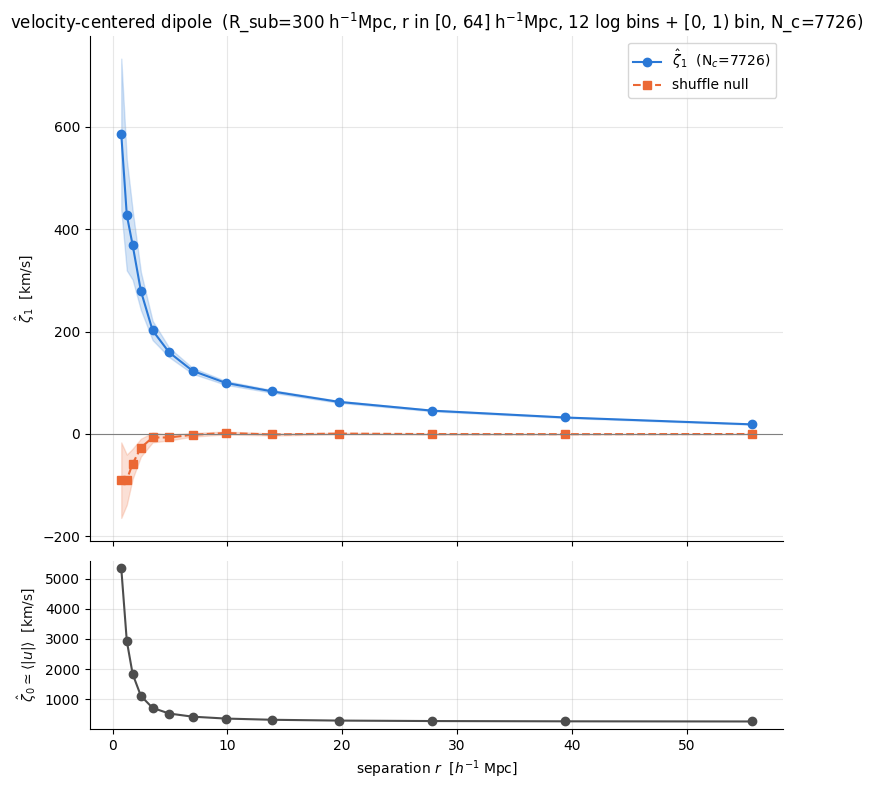

In [7]:
# The figure lives in this notebook's own cell output -- no PNG is written
# anywhere. Re-run the notebook to refresh it. The trailing bare `fig` of
# earlier versions is gone deliberately: `%matplotlib inline` already renders
# the figure at the end of the cell, so echoing it stored the same PNG twice.
fig = make_figure(cfg, result, normalized)